### Dependencies 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
from ScOPE import generate_samples
from ScOPE.model import ScOPEModel

### Random seed

In [3]:
np.random.seed(4112345)

#### test

In [4]:
SMILES_COLUMN:str = 'smiles'
LABEL_COLUMN:str = 'CT_TOX'
FILE_PATH:str = 'data/clintox.csv'
dataF:pd.DataFrame = pd.read_csv(FILE_PATH)
dataF.head()

,smiles,FDA_APPROVED,CT_TOX
0,*C(=O)[C@H](CCCCNC(=O)OCCOC)NC(=O)OCCOC,1,0
1,[C@@H]1([C@@H]([C@@H]([C@H]([C@@H]([C@@H]1Cl)C...,1,0
2,[C@H]([C@@H]([C@@H](C(=O)[O-])O)O)([C@H](C(=O)...,1,0
3,[H]/[NH+]=C(/C1=CC(=O)/C(=C\C=c2ccc(=C([NH3+])...,1,0
4,[H]/[NH+]=C(\N)/c1ccc(cc1)OCCCCCOc2ccc(cc2)/C(...,1,0


In [5]:
X = dataF[SMILES_COLUMN].values
Y = dataF[LABEL_COLUMN].values
tests: tuple = generate_samples(X, Y, samples=20)

model = ScOPEModel(method='dice',
                   compressor_name='bz2',
                   distance_name='ncd',
                   append_type='text',
                   )
all_y_true:list = []
all_y_pred:list = []
all_auc_score:list = []

for test in tests:
    temp_x, kw_samples, y_true = test
    y_pred = model.predict(temp_x, *kw_samples, softmax=True)
    all_y_pred.append(y_pred.argmax())
    all_auc_score.append(y_pred)
    all_y_true.append(y_true)

In [6]:
confusion_matrix(all_y_true, all_y_pred, normalize='true')

array([[0.84037901, 0.15962099],
       [0.27678571, 0.72321429]])

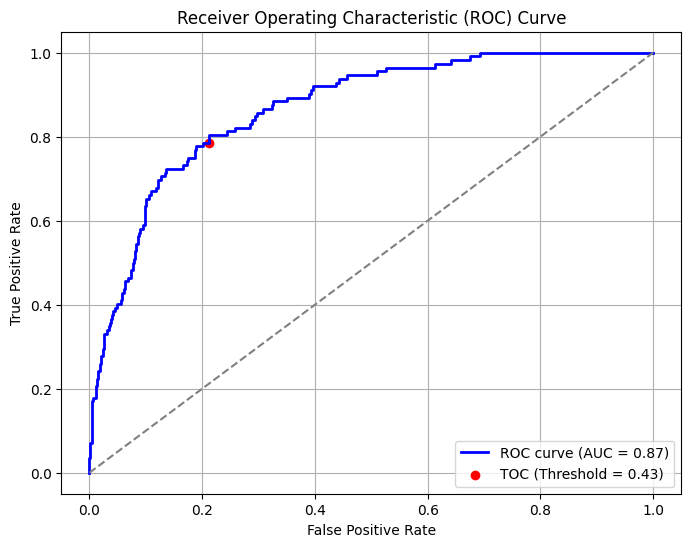

In [7]:
fpr, tpr, thresholds = roc_curve(all_y_true, np.array(all_auc_score)[:, 1])
auc_roc  = roc_auc_score(all_y_true, np.array(all_auc_score)[:, 1])

optimal_idx = (np.abs(tpr - (1-fpr))).argmin()
optimal_threshold = thresholds[optimal_idx]

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % auc_roc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', label=f'TOC (Threshold = {optimal_threshold:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()